# Self-study try-it activity 14.1: Selecting hyperplanes for two-dimensional data

## Assignment overview:

In this assignment, you will work with two different sets of data points — one exhibiting a linear pattern and the other a non-linear pattern. Your task is to determine which type of kernel performs best for each data set and provide a rationale for your selection.



In [1]:
# Import the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Use the following to plot SVMs.
from mlxtend.plotting import plot_decision_regions # On terminal, install: pip install mlxtend

#### Task 1: SVM-based classifier on a simple data set
Load the two-dimensional data `Case1linear/X.npy` that has 20 rows and two columns, and the corresponding target `Case1linear/y.npy.`

In [21]:
n = 20 # n points in each group
# number used for colour array construction (assumes balanced classes)
X = np.load('data/Case1linear/X.npy')
y = np.load('data/Case1linear/y.npy')
print(f"Shape of X: {X.shape}")
print(X[:,0])
print(y)

Shape of X: (40, 2)
[ 0.07094787  0.03636592  0.11297143  0.00076906 -0.12104728 -0.08967344
  0.16439342  0.20135346  0.15187732 -0.15442953  0.07528085  0.09611417
 -0.17315404 -0.25226348 -0.33278024 -0.07926065  0.03224639 -0.03808561
 -0.14958058  0.00531245  0.41421784  0.7003747   0.44936071  0.48276201
  0.02788752  0.53487357  0.32776809  0.65014141  0.52396815  0.50757842
  0.64153631  0.48748262  0.58340906  0.27065218  0.32506119  0.4842098
  0.71115916  0.7206851   0.43079076  0.41422749]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]


**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

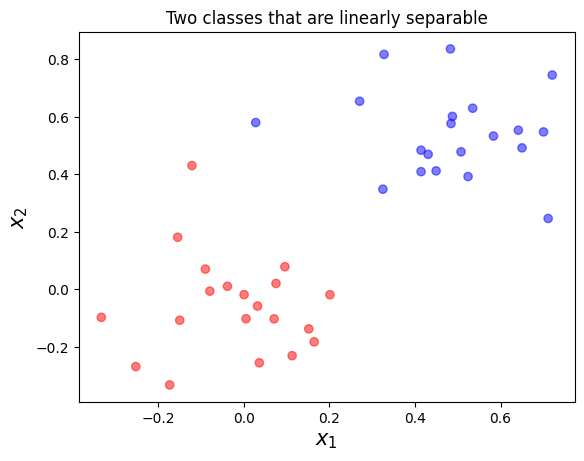

In [3]:
color = np.concatenate((np.repeat("red", n), np.repeat("blue",n)), axis=0) #y is split half half
plt.scatter(X[:,0], X[:,1], c = color, alpha= .5)
plt.xlabel("$x_1$", size = 15)
plt.ylabel("$x_2$", size = 15)
plt.title("Two classes that are linearly separable")
plt.show()

**Train an SVM classifier with a linear kernel.**

In [4]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);

**Show the confusion matrix on the training set.**

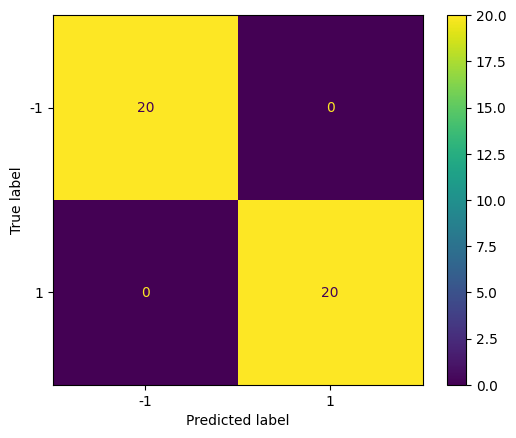

In [5]:
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

**Visualise the decision boundary of the kernel by using the `mlxtend` package.**

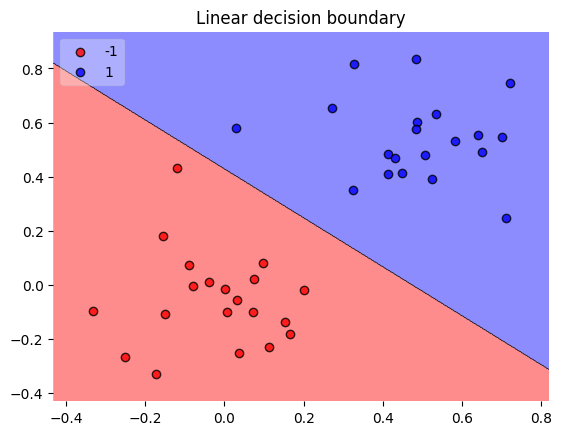

In [6]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples belong to the same class.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.title("Linear decision boundary")
    plt.show();

## Question:
Relate the visualisation of the decision boundary with the performance observed in the confusion matrix.

## Answer:
The data is linearly separable, as shown in the visualisation, so the confusion matrix indicates perfect classification.

#### Task 2: SVM-based classifier on nested data
Load the two-dimensional data `Case1rings/X.npy` that has 150 rows and two columns, and the corresponding target `Case1rings/y.np`.

In [22]:
X = np.load('data/Case1rings/X.npy')
y = np.load('data/Case1rings/y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

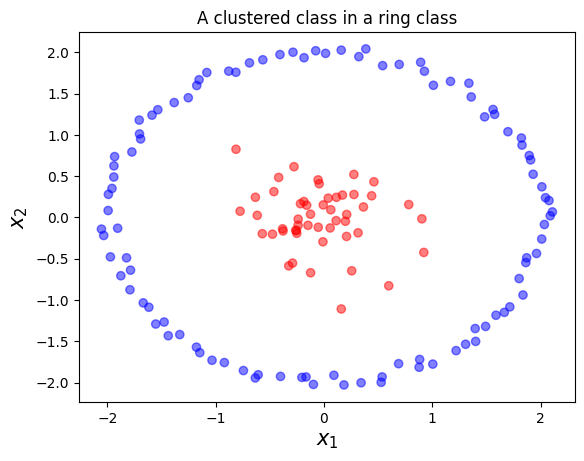

In [23]:
n = 100
color = np.concatenate((np.repeat("blue", n), np.repeat("red",n/2)), axis=0)
plt.scatter(X[:,0], X[:,1], c = color, alpha= .5)
plt.xlabel("$x_1$", size = 15)
plt.ylabel("$x_2$", size = 15)
plt.title("A clustered class in a ring class")
plt.show()

**Train an SVM classifier with a linear kernel.**

In [9]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);

**Show the confusion matrix on the training set.**

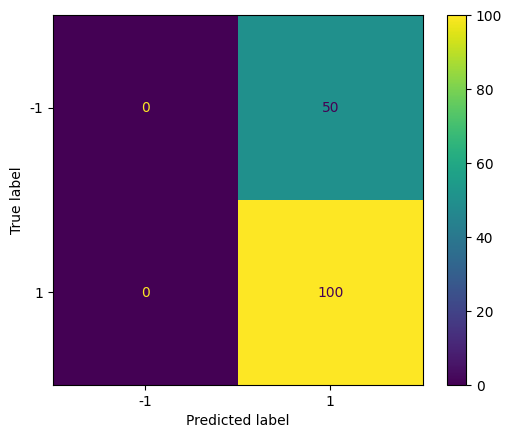

In [10]:
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

**Visualise the decision boundary of the kernel by using the `mlxtend` package.**

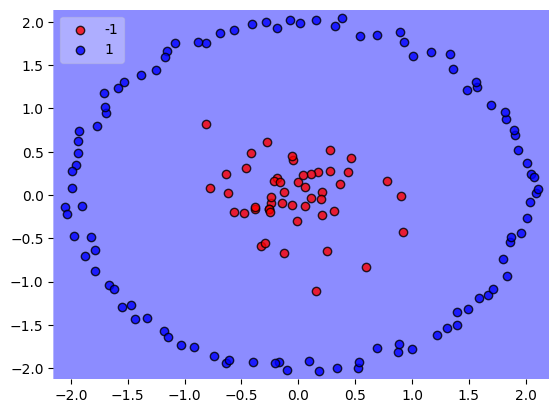

In [11]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples belong to the same class.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

**Train an SVM classifier with a radial kernel.**

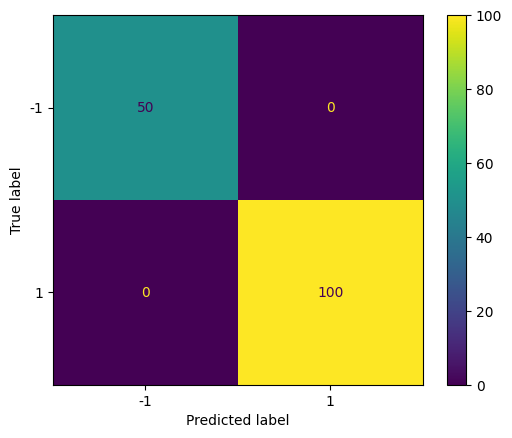

In [12]:
clf = svm.SVC(kernel = 'rbf')
clf.fit(X, y)
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

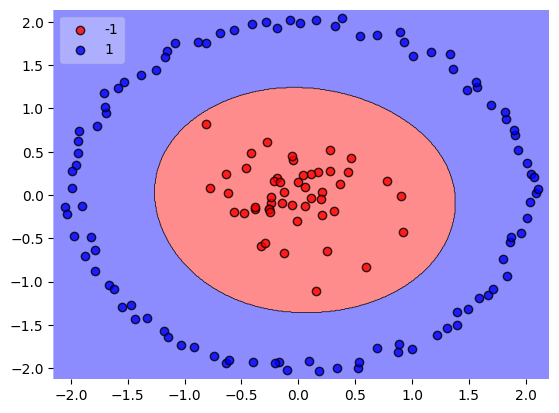

In [13]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples are classified as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

**Try polynomial kernel with degree 2.**

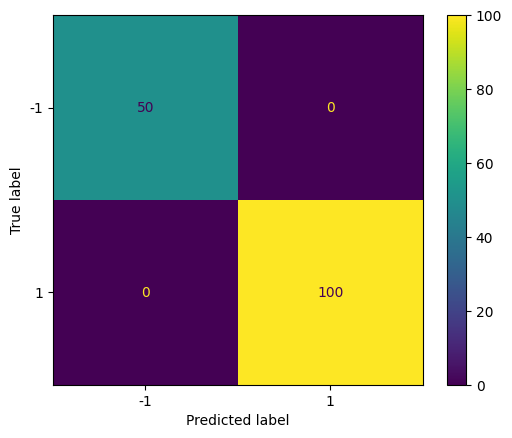

In [14]:
clf = svm.SVC(kernel = 'poly', degree = 2)
clf.fit(X, y)
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

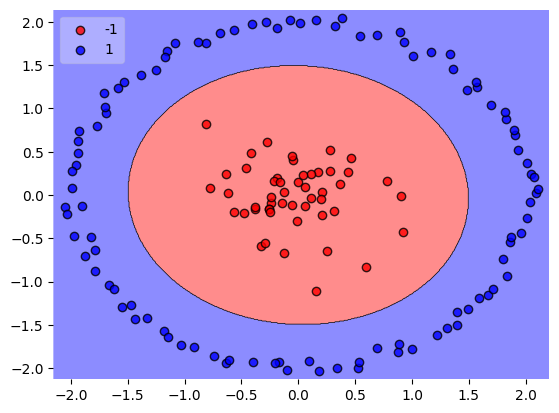

In [15]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples are classified as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.show();

## Question:
Compare the classifiers obtained in this case and discuss why some are better than others.

## Answer:

RBF and polynomial kernels succeed because they model non-linear decision boundaries, whereas linear SVM fails on non-linearly separable data.